In [ ]:
# 시각적 탐색 - matplotlib 라이브러리
# seaborn 라이브러리(matplotlib 기본 베이스로 한다) : 더 많은 차트를 표현. 간단한 표현. 통계

In [1]:
import pandas as pd
from pandas.api.types import CategoricalDtype
import matplotlib.pyplot as plt

# 차트에 한글 깨지지 않도록 차트 폰트변경
plt.rcParams['font.family'] = 'Malgun Gothic'
# 차트에 "-"문자 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# BostonHousing.csv 파일 로드
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

df = pd.read_csv(url)

display(df.head())

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [3]:
# 데이터 크기
display(df.shape)

# 정보
display(df.info())

# 기술통계
display(df.describe())

# 결측치
display(df.isnull().sum())

# 변수명
display(df.columns)

(506, 14)

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


None

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='str')

In [4]:
# 필요한 변수만 선택 - 시각화 탐색 -> 분포(hist, box, ...), 상관관계(산점도)
df2 = df[["crim", "rm", "dis", "tax", "medv"]]

display(df2.head())

,crim,rm,dis,tax,medv
0,0.00632,6.575,4.0900,296,24.0
1,0.02731,6.421,4.9671,242,21.6
2,0.02729,7.185,4.9671,242,34.7
3,0.03237,6.998,6.0622,222,33.4
4,0.06905,7.147,6.0622,222,36.2


In [5]:
# medv 기준으로 등급 생성
# grade 열을 먼저 생성 : 기본값으로 전부 "하"
df2["grade"] = "하"

# medv가 17 이상이면 중
df2.loc[df2["medv"] >= 17, "grade"] = "중"

# medv가 25 이상이면 상
df2.loc[df2["medv"] >= 25, "grade"] = "상"


# category 타입으로 변환
df2["grade"] = df2["grade"].astype("category") # df2["grade"] category 타입으로 변경된 df2["grade"]열을 덮어쓰기

display(df2.head())
display(df2.tail())
display(df2.dtypes)

df2.grade.value_counts()

,crim,rm,dis,tax,medv,grade
0,0.00632,6.575,4.0900,296,24.0,중
1,0.02731,6.421,4.9671,242,21.6,중
2,0.02729,7.185,4.9671,242,34.7,상
3,0.03237,6.998,6.0622,222,33.4,상
4,0.06905,7.147,6.0622,222,36.2,상


,crim,rm,dis,tax,medv,grade
501,0.06263,6.593,2.4786,273,22.4,중
502,0.04527,6.120,2.2875,273,20.6,중
503,0.06076,6.976,2.1675,273,23.9,중
504,0.10959,6.794,2.3889,273,22.0,중
505,0.04741,6.030,2.5050,273,11.9,하


crim      float64
rm        float64
dis       float64
tax         int64
medv      float64
grade    category
dtype: object

grade
중    248
상    132
하    126
Name: count, dtype: int64

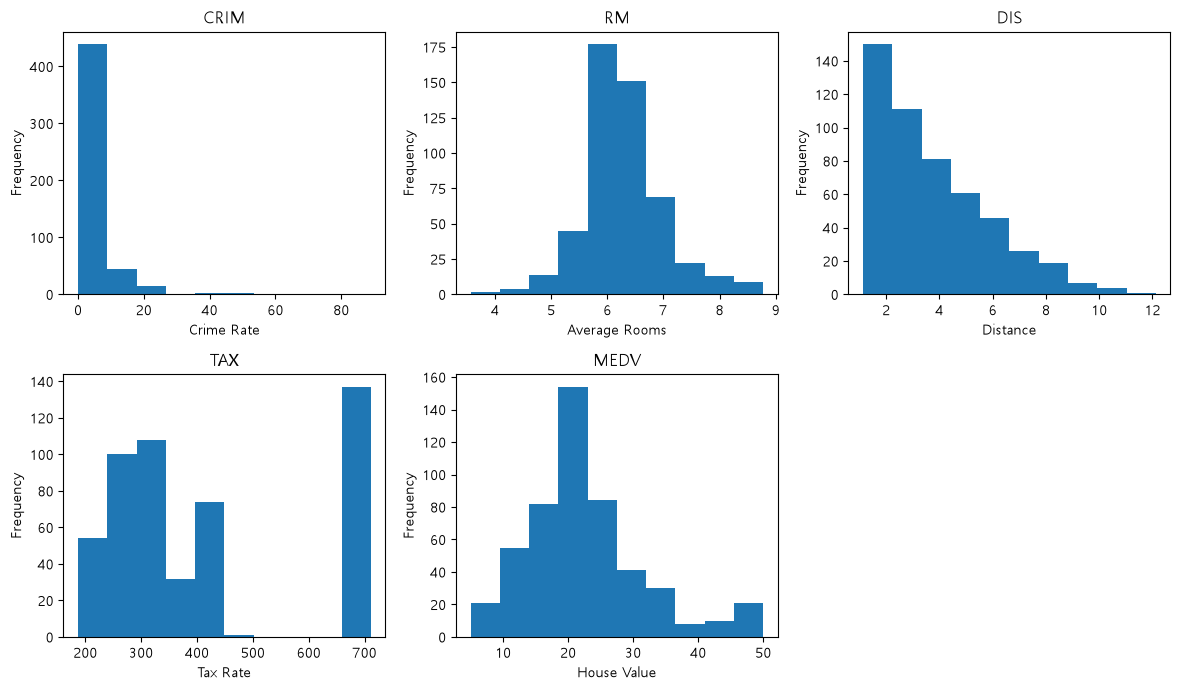

In [6]:
fig = plt.figure(figsize=(12, 7))

# 1행 1열
axes1 = fig.add_subplot(2, 3, 1)
axes1.hist(df2["crim"])
axes1.set_title("CRIM")
axes1.set_xlabel("Crime Rate")
axes1.set_ylabel("Frequency")

# 1행 2열
axes2 = fig.add_subplot(2, 3, 2)
axes2.hist(df2["rm"])
axes2.set_title("RM")
axes2.set_xlabel("Average Rooms")
axes2.set_ylabel("Frequency")

# 1행 3열
axes3 = fig.add_subplot(2, 3, 3)
axes3.hist(df2["dis"])
axes3.set_title("DIS")
axes3.set_xlabel("Distance")
axes3.set_ylabel("Frequency")

# 2행 1열
axes4 = fig.add_subplot(2, 3, 4)
axes4.hist(df2["tax"])
axes4.set_title("TAX")
axes4.set_xlabel("Tax Rate")
axes4.set_ylabel("Frequency")

# 2행 2열
axes5 = fig.add_subplot(2, 3, 5)
axes5.hist(df2["medv"])
axes5.set_title("MEDV")
axes5.set_xlabel("House Value")
axes5.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [ ]:
# CRIM
# 대부분 낮은 값에 집중되어 있다.
# 일부 매우 큰 값이 있어 오른쪽으로 치우친 분포를 보인다.

# RM
# 평균 방 개수는 주로 5~7개 정도에 집중되어 있다.
# 비교적 종 모양에 가까운 분포다.

# DIS
# 주로 2~6 정도의 값에 분포한다.
# 극단적으로 큰 값은 많지 않다.

# TAX
# 특정 세율 구간에 데이터가 많이 몰려 있다.
# 값의 분포가 고르게 퍼져 있지 않고 일부 구간에 집중되어 있다.

# MEDV
# 주택 가격은 주로 15~30 정도에 많이 분포한다.
# 높은 가격대에도 데이터가 있으며, 50에서 값이 제한된 현상이 나타난다.

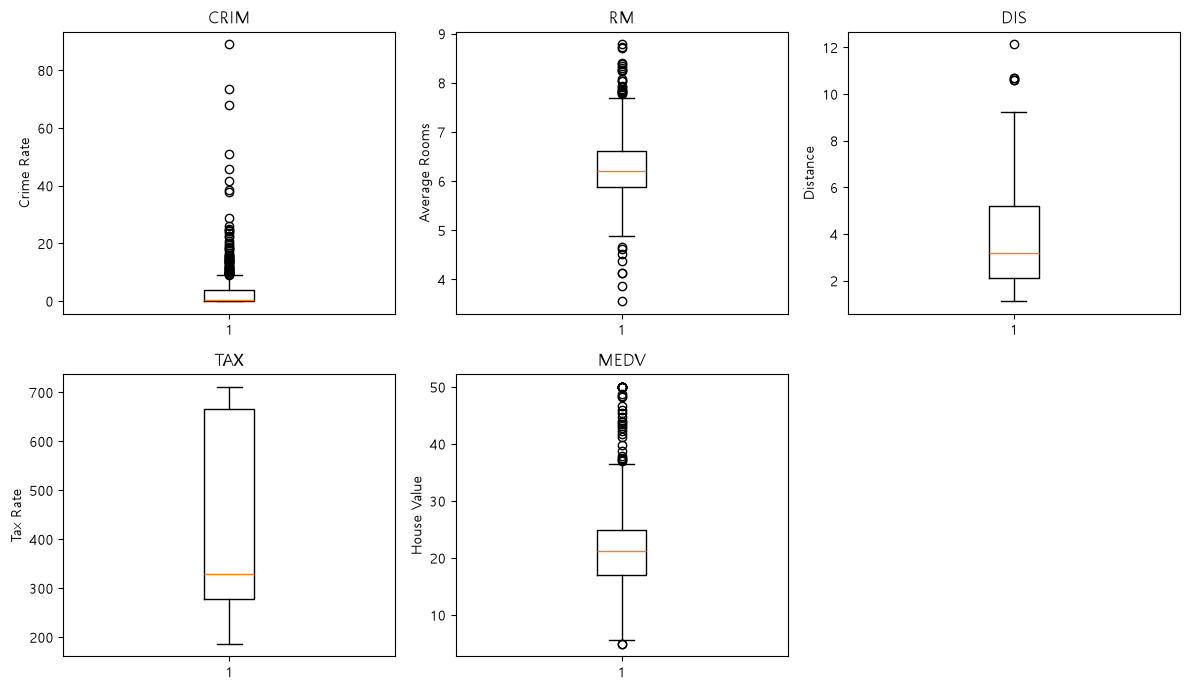

In [7]:
fig = plt.figure(figsize=(12, 7))

axes1 = fig.add_subplot(2, 3, 1)
axes1.boxplot(df2["crim"])
axes1.set_title("CRIM")
axes1.set_ylabel("Crime Rate")

axes2 = fig.add_subplot(2, 3, 2)
axes2.boxplot(df2["rm"])
axes2.set_title("RM")
axes2.set_ylabel("Average Rooms")

axes3 = fig.add_subplot(2, 3, 3)
axes3.boxplot(df2["dis"])
axes3.set_title("DIS")
axes3.set_ylabel("Distance")

axes4 = fig.add_subplot(2, 3, 4)
axes4.boxplot(df2["tax"])
axes4.set_title("TAX")
axes4.set_ylabel("Tax Rate")

axes5 = fig.add_subplot(2, 3, 5)
axes5.boxplot(df2["medv"])
axes5.set_title("MEDV")
axes5.set_ylabel("House Value")

plt.tight_layout()
plt.show()

In [ ]:
# CRIM
# 상자 위쪽으로 많은 이상치가 나타난다.
# 일부 지역의 범죄율이 매우 높아 오른쪽으로 치우친 분포다.

# RM
# 이상치가 일부 존재한다.
# 대부분의 값은 비교적 좁은 범위에 분포한다.

# DIS
# 일부 높은 값이 이상치로 나타난다.
# 중앙값을 기준으로 비교적 안정적인 분포를 보인다.

# TAX
# 이상치는 많지 않지만 값의 범위가 비교적 넓다.
# 일부 세율이 다른 데이터보다 크게 나타난다.

# MEDV
# 높은 주택가격 쪽에 이상치가 나타난다.
# 특히 50 부근에 값이 집중되는 현상이 보인다.
# 따라서 실제 이상치와 데이터의 상한값 제한(50)을 구분해서 해석할 필요가 있다.

In [8]:
# grade별 데이터 분리
low = df2[df2["grade"] == "하"]
middle = df2[df2["grade"] == "중"]
high = df2[df2["grade"] == "상"]

display(low)
display(middle)
display(high)

,crim,rm,dis,tax,medv,grade
8,0.21124,5.631,6.0821,311,16.5,하
10,0.22489,6.377,6.3467,311,15.0,하
20,1.25179,5.570,3.7979,307,13.6,하
22,1.23247,6.142,3.9769,307,15.2,하
23,0.98843,5.813,4.0952,307,14.5,하
...,...,...,...,...,...,...
489,0.18337,5.414,1.7554,711,7.0,하
490,0.20746,5.093,1.8226,711,8.1,하
491,0.10574,5.983,1.8681,711,13.6,하
500,0.22438,6.027,2.4982,391,16.8,하


,crim,rm,dis,tax,medv,grade
0,0.00632,6.575,4.0900,296,24.0,중
1,0.02731,6.421,4.9671,242,21.6,중
6,0.08829,6.012,5.5605,311,22.9,중
9,0.17004,6.004,6.5921,311,18.9,중
11,0.11747,6.009,6.2267,311,18.9,중
...,...,...,...,...,...,...
499,0.17783,5.569,2.3999,391,17.5,중
501,0.06263,6.593,2.4786,273,22.4,중
502,0.04527,6.120,2.2875,273,20.6,중
503,0.06076,6.976,2.1675,273,23.9,중


,crim,rm,dis,tax,medv,grade
2,0.02729,7.185,4.9671,242,34.7,상
3,0.03237,6.998,6.0622,222,33.4,상
4,0.06905,7.147,6.0622,222,36.2,상
5,0.02985,6.430,6.0622,222,28.7,상
7,0.14455,6.172,5.9505,311,27.1,상
...,...,...,...,...,...,...
372,8.26725,5.875,1.1296,666,50.0,상
407,11.95110,5.608,1.2852,666,27.9,상
409,14.43830,6.852,1.4655,666,27.5,상
473,4.64689,6.980,2.5329,666,29.8,상


In [ ]:
# 수치화 -> 의미 분석 X -> 분포 특성
# 구간화, 범주화, 그룹화, 층화

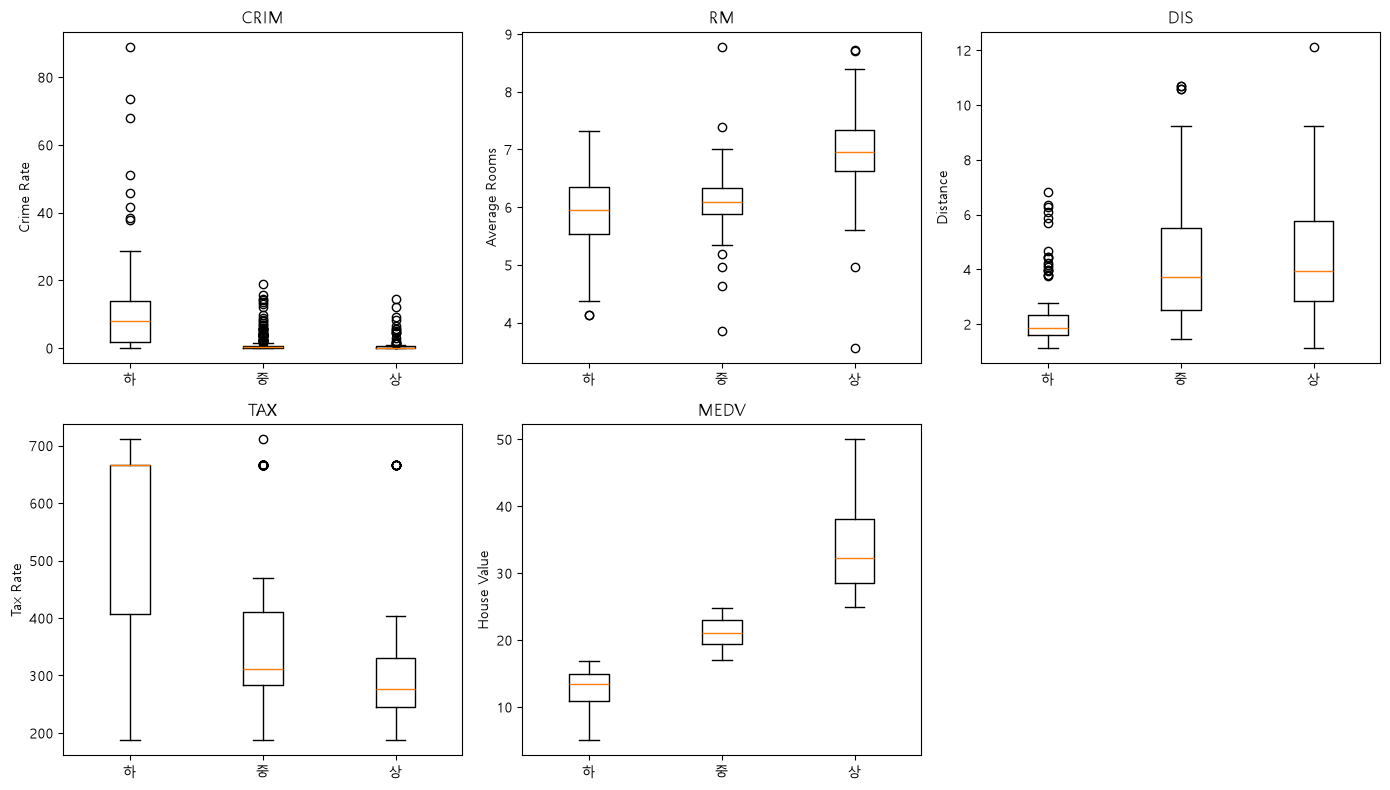

In [9]:
fig = plt.figure(figsize=(14, 8))

# 1. CRIM
axes1 = fig.add_subplot(2, 3, 1)

axes1.boxplot([
    low["crim"],
    middle["crim"],
    high["crim"]
])

axes1.set_title("CRIM")
axes1.set_xticklabels(["하", "중", "상"])
axes1.set_ylabel("Crime Rate")


# 2. RM
axes2 = fig.add_subplot(2, 3, 2)

axes2.boxplot([
    low["rm"],
    middle["rm"],
    high["rm"]
])

axes2.set_title("RM")
axes2.set_xticklabels(["하", "중", "상"])
axes2.set_ylabel("Average Rooms")


# 3. DIS
axes3 = fig.add_subplot(2, 3, 3)

axes3.boxplot([
    low["dis"],
    middle["dis"],
    high["dis"]
])

axes3.set_title("DIS")
axes3.set_xticklabels(["하", "중", "상"])
axes3.set_ylabel("Distance")


# 4. TAX
axes4 = fig.add_subplot(2, 3, 4)

axes4.boxplot([
    low["tax"],
    middle["tax"],
    high["tax"]
])

axes4.set_title("TAX")
axes4.set_xticklabels(["하", "중", "상"])
axes4.set_ylabel("Tax Rate")


# 5. MEDV
axes5 = fig.add_subplot(2, 3, 5)

axes5.boxplot([
    low["medv"],
    middle["medv"],
    high["medv"]
])

axes5.set_title("MEDV")
axes5.set_xticklabels(["하", "중", "상"])
axes5.set_ylabel("House Value")


plt.tight_layout()
plt.show()

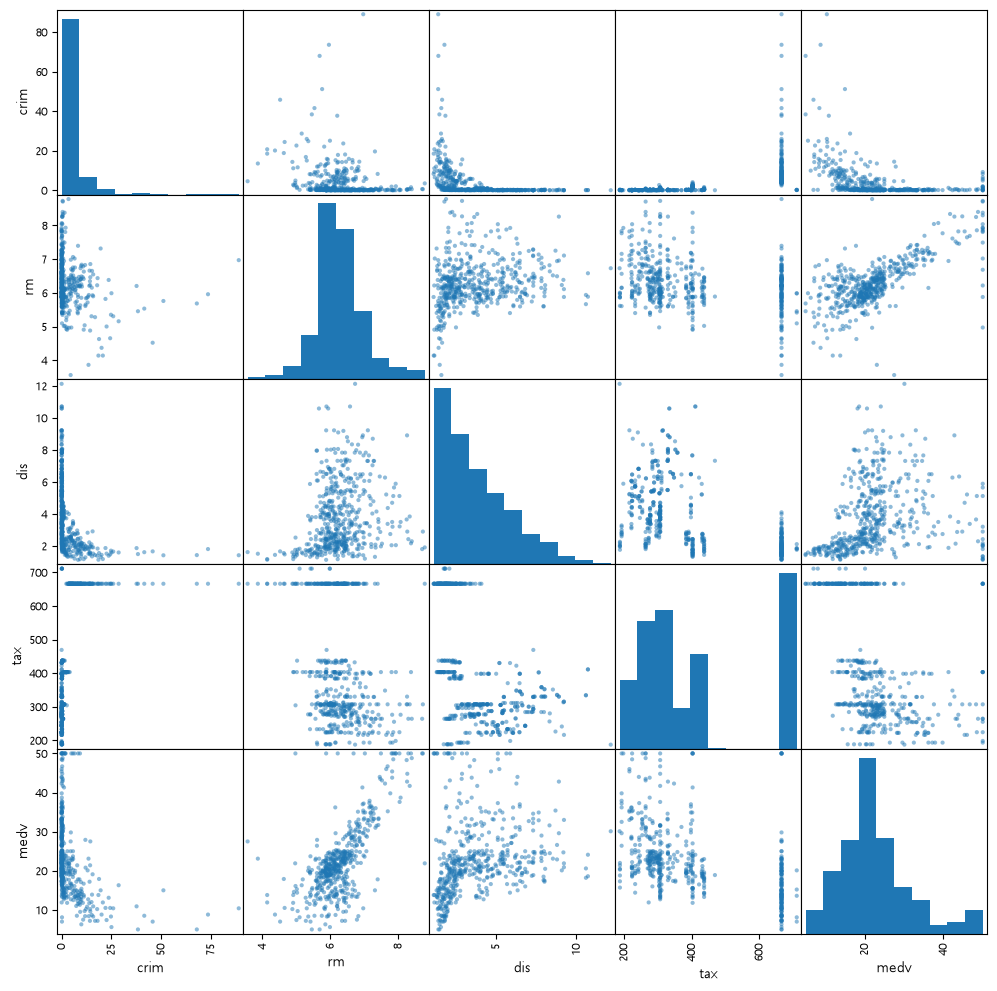

In [10]:
from pandas.plotting import scatter_matrix

scatter_matrix(
    df2[["crim", "rm", "dis", "tax", "medv"]],
    figsize=(12, 12),
    diagonal="hist"
)

plt.show()

# 5개 변수이므로 5 × 5 = 25개의 그래프가 만들어진다.
# 대각선: 각 변수의 히스토그램
# 대각선 이외: 두 변수 간 산점도
# 따라서 변수 간 관계와 분포를 동시에 확인할 수 있다.

In [ ]:
# RM ↔ MEDV: 양의 상관관계가 비교적 뚜렷하다. → 방 개수가 많을수록 주택가격이 높아지는 경향
# CRIM ↔ MEDV: 음의 관계가 나타난다. → 범죄율이 높을수록 주택가격이 낮아지는 경향
# DIS ↔ MEDV: 뚜렷한 선형관계는 상대적으로 약하다.
# TAX ↔ MEDV: 음의 관계가 나타나는 편이다.
# CRIM, TAX 등은 일부 극단적인 값이 있어 산점도에서 이상치도 함께 확인할 수 있다.

#              crim    rm     dis    tax    medv
#           ┌──────┬──────┬──────┬──────┬──────┐
#    crim   │ 분포 │ 관계 │ 관계 │ 관계 │ 관계 │
#    rm     │ 관계 │ 분포 │ 관계 │ 관계 │ 관계 │
#    dis    │ 관계 │ 관계 │ 분포 │ 관계 │ 관계 │
#    tax    │ 관계 │ 관계 │ 관계 │ 분포 │ 관계 │
#    medv   │ 관계 │ 관계 │ 관계 │ 관계 │ 분포 │
#           └──────┴──────┴──────┴──────┴──────┘

In [11]:
# 수치(상관계수)를 사용하여 확인
# 상관계수
# 1 에 가까움	강한 양의 상관관계
# 0 에 가까움	상관관계가 약함
# -1 에 가까움	강한 음의 상관관계

corr = df2[["crim", "rm", "dis", "tax", "medv"]].corr()

display(corr)

,crim,rm,dis,tax,medv
crim,1.000000,-0.219247,-0.379670,0.582764,-0.388305
rm,-0.219247,1.000000,0.205246,-0.292048,0.695360
dis,-0.379670,0.205246,1.000000,-0.534432,0.249929
tax,0.582764,-0.292048,-0.534432,1.000000,-0.468536
medv,-0.388305,0.695360,0.249929,-0.468536,1.000000


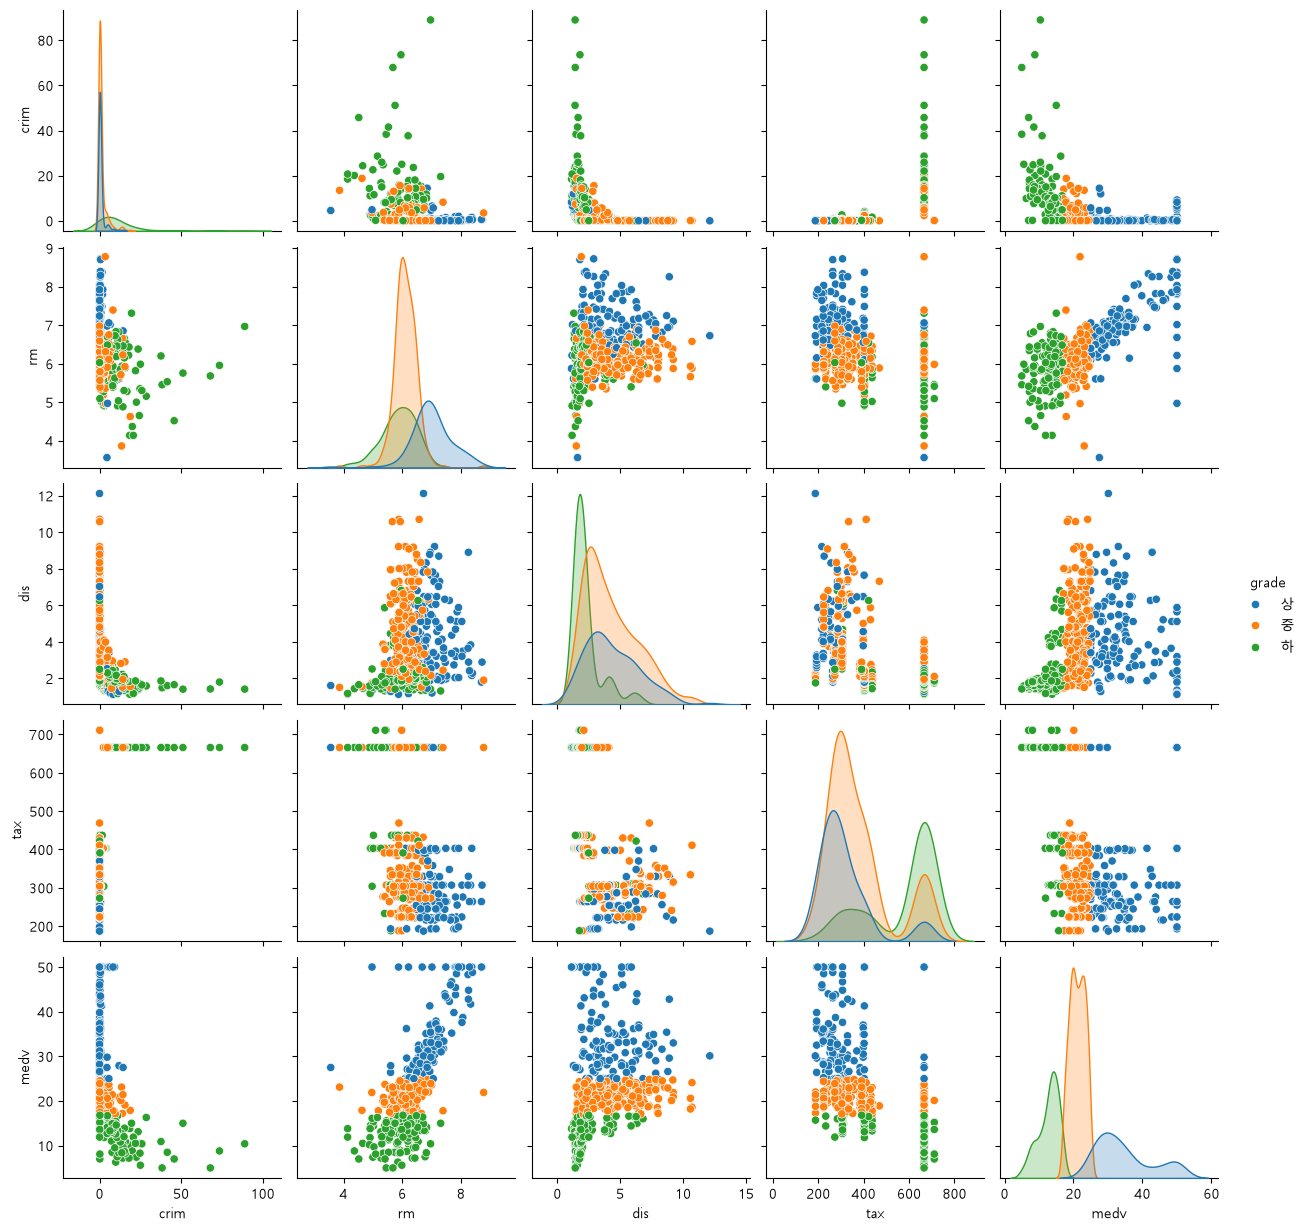

In [12]:
# seaborn 라이브러리를 활용하여 간단하게 다양한 시각화가 가능하다.
# seaborn 라이브러리는 뒤에서 다시 설명한다.

# [과제]
# 다음 시각화 결과를 해석

import seaborn as sns

sns.pairplot(
    df2[["crim", "rm", "dis", "tax", "medv", "grade"]],
    hue="grade"
)

plt.show()

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


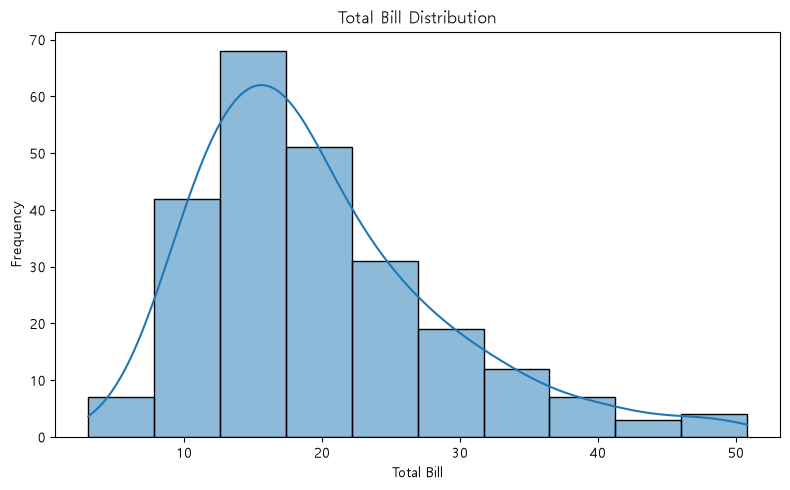

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 1. 데이터 준비
# ============================================================

# Seaborn에서 제공하는 tips 데이터셋을 불러온다.
tips = sns.load_dataset("tips")

# 데이터 확인
print(tips.head())


# ============================================================
# 2. 전체 Figure 생성
# ============================================================

# 전체 그래프를 담을 큰 도화지(Figure)를 생성한다.
fig = plt.figure(figsize=(8, 5))


# ============================================================
# 3. 그래프 공간(Axes) 생성
# ============================================================

# 1행 1열 중 첫 번째 위치에
# 그래프 공간(Axes)을 생성한다.
axes1 = fig.add_subplot(1, 1, 1)


# ============================================================
# 4. 히스토그램 + 밀도 차트 그리기
# ============================================================

# total_bill의 분포를 히스토그램으로 표현한다.
#
# histplot()
# → 히스토그램을 그리는 Seaborn 함수
#
# kde=True
# → KDE(Kernel Density Estimation)
#   즉, 밀도 곡선을 함께 표시한다.
#
# bins=10
# → 히스토그램의 구간을 10개로 나눈다.

sns.histplot(
    data=tips,
    x="total_bill",
    bins=10,
    kde=True,
    ax=axes1
)


# ============================================================
# 5. 그래프 설정
# ============================================================

# 그래프 제목
axes1.set_title("Total Bill Distribution")

# x축 이름
axes1.set_xlabel("Total Bill")

# y축 이름
axes1.set_ylabel("Frequency")


# ============================================================
# 6. 그래프 간격 조정
# ============================================================

fig.tight_layout()


# ============================================================
# 7. Figure 출력
# ============================================================

plt.show()

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


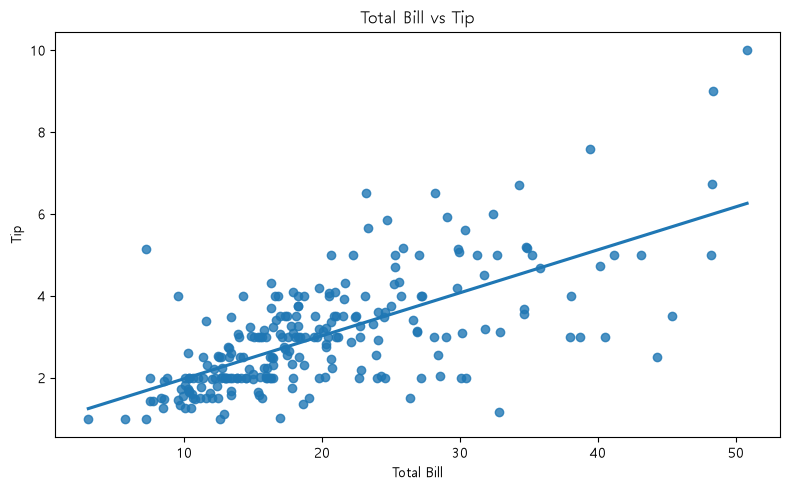

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 1. 데이터 준비
# ============================================================

# Seaborn에서 제공하는 tips 데이터셋을 불러온다.
tips = sns.load_dataset("tips")

# 데이터 확인
print(tips.head())


# ============================================================
# 2. 전체 Figure 생성
# ============================================================

# 전체 그래프를 담을 큰 도화지(Figure)를 생성한다.
fig = plt.figure(figsize=(8, 5))


# ============================================================
# 3. 그래프 공간(Axes) 생성
# ============================================================

# 1행 1열 중 첫 번째 위치에
# 그래프 공간(Axes)을 생성한다.
axes1 = fig.add_subplot(1, 1, 1)


# ============================================================
# 4. 산점도 + 회귀선 그리기
# ============================================================

# total_bill과 tip의 관계를 산점도로 표시하고
# 두 변수의 선형적인 관계를 나타내는 회귀선을 함께 그린다.
#
# data=tips
# → 사용할 데이터프레임
#
# x="total_bill"
# → x축에 사용할 열
#
# y="tip"
# → y축에 사용할 열
#
# ax=axes1
# → 우리가 만든 axes1 공간에 그래프를 그린다.
#
# ci=None
# → 회귀선 주변의 신뢰구간을 표시하지 않는다.
# → 입문 예제에서는 회귀선만 보여주기 위해 사용한다.

sns.regplot(
    data=tips,
    x="total_bill",
    y="tip",
    ax=axes1,
    ci=None
)


# ============================================================
# 5. 그래프 설정
# ============================================================

# 그래프 제목
axes1.set_title("Total Bill vs Tip")

# x축 이름
axes1.set_xlabel("Total Bill")

# y축 이름
axes1.set_ylabel("Tip")


# ============================================================
# 6. Figure 간격 조정
# ============================================================

fig.tight_layout()


# ============================================================
# 7. Figure 출력
# ============================================================

plt.show()

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


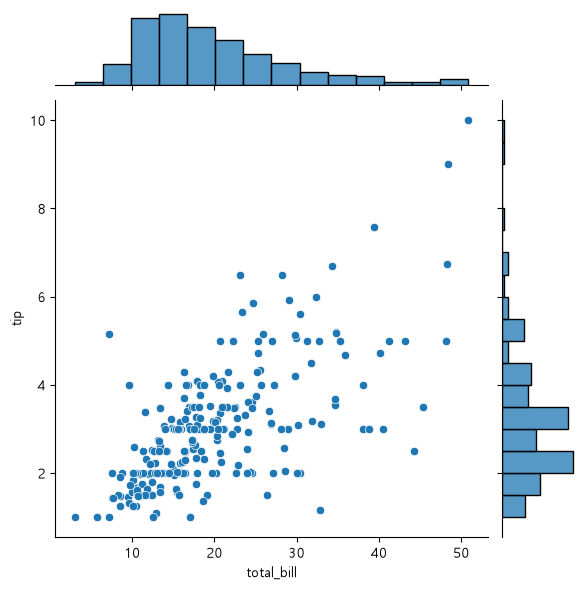

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 1. 데이터 준비
# ============================================================

# Seaborn에서 제공하는 tips 데이터셋을 불러온다.
tips = sns.load_dataset("tips")

# 데이터 확인
print(tips.head())


# ============================================================
# 2. 산점도 + 히스토그램
# ============================================================

# jointplot()
# → 두 변수의 관계와 각 변수의 분포를 동시에 보여준다.
#
# 가운데 → 산점도
# 위쪽   → x축 변수의 히스토그램
# 오른쪽 → y축 변수의 히스토그램
#
# x="total_bill"
# → x축 변수
#
# y="tip"
# → y축 변수

sns.jointplot(
    data=tips,
    x="total_bill",
    y="tip"
)


# ============================================================
# 3. 그래프 출력
# ============================================================

plt.show()

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


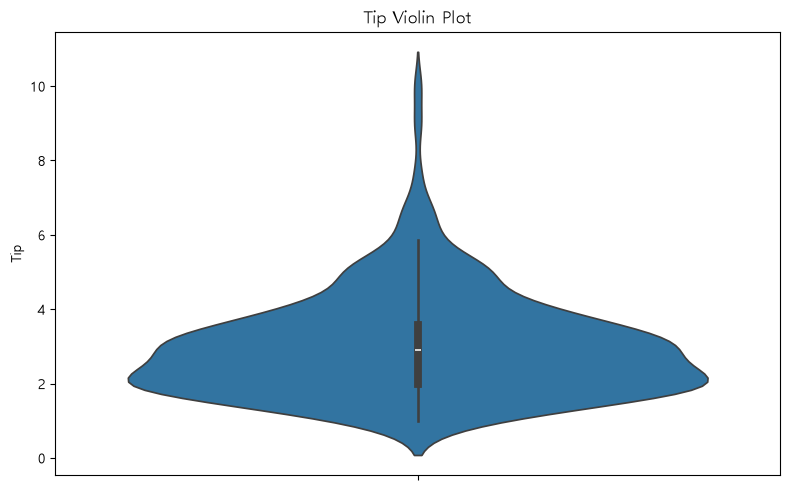

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# tips 데이터 불러오기
tips = sns.load_dataset("tips")

# 데이터 확인
print(tips.head())

# Figure 생성
fig = plt.figure(figsize=(8, 5))

# Figure 안에 1개의 Axes 생성
axes1 = fig.add_subplot(1, 1, 1)

# tip의 분포를 바이올린 형태로 표현
sns.violinplot(
    data=tips,
    y="tip",
    ax=axes1
)

# 제목과 축 이름 설정
axes1.set_title("Tip Violin Plot")
axes1.set_ylabel("Tip")

# 그래프 여백 정리
fig.tight_layout()

# 그래프 출력
plt.show()

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
sex
Male      157
Female     87
Name: count, dtype: int64


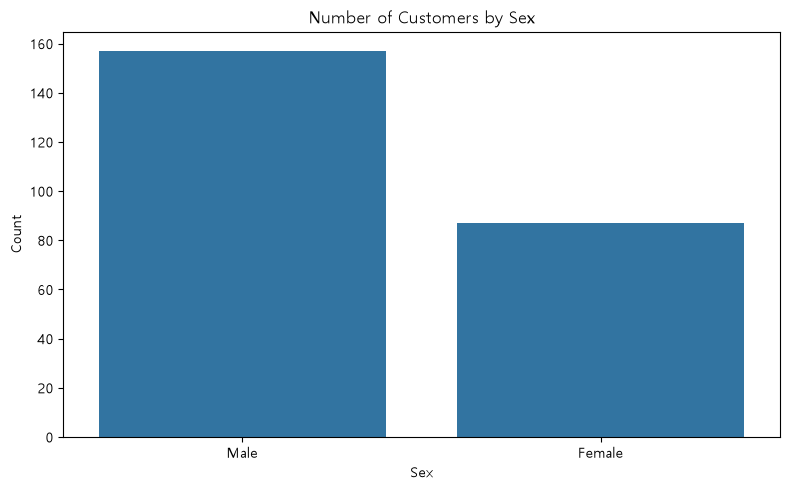

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# tips 데이터 불러오기
tips = sns.load_dataset("tips")

# 데이터 확인
print(tips.head())

# 성별 데이터 개수 확인
print(tips["sex"].value_counts())

# Figure 생성
fig = plt.figure(figsize=(8, 5))

# Figure 안에 1개의 Axes 생성
axes1 = fig.add_subplot(1, 1, 1)


# Matplotlib에는 countplot()이라는 함수가 없다. 
# 따라서 범주별 개수를 먼저 계산한 다음 bar()로 그려야 한다.

# 성별별 데이터 개수를 막대그래프로 표현
sns.countplot(
    data=tips,
    x="sex",
    ax=axes1
)

# 제목과 축 이름 설정
axes1.set_title("Number of Customers by Sex")
axes1.set_xlabel("Sex")
axes1.set_ylabel("Count")

# 그래프 여백 정리
fig.tight_layout()

# 그래프 출력
plt.show()

In [ ]:
# 데이터 탐색 - 시각적 - 현재 데이터 시각적 matplotlib - 자동으로 통계적 수치를 구해서 시각화 seaborn

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


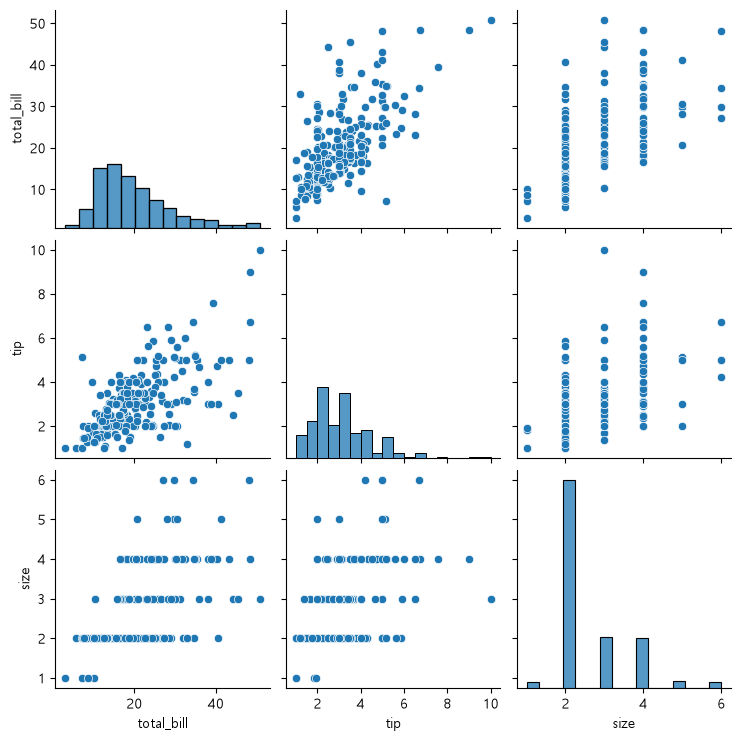

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# tips 데이터 불러오기
tips = sns.load_dataset("tips")

# 데이터 확인
print(tips.head())

# 여러 변수의 관계를 한꺼번에 시각화
sns.pairplot(
    data=tips
)

# 그래프 출력
plt.show()

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  
                   mpg  cylinders  displacement  horsepower    weight  \
mpg           1.000000  -0.775396     -0.804203   -0.778427 -0.831741   
cylinders    -0.775396   1.000000      0.950721    0.842983  0.896017   
displacement -0.804203   0.950721      1.000000    0.897257 

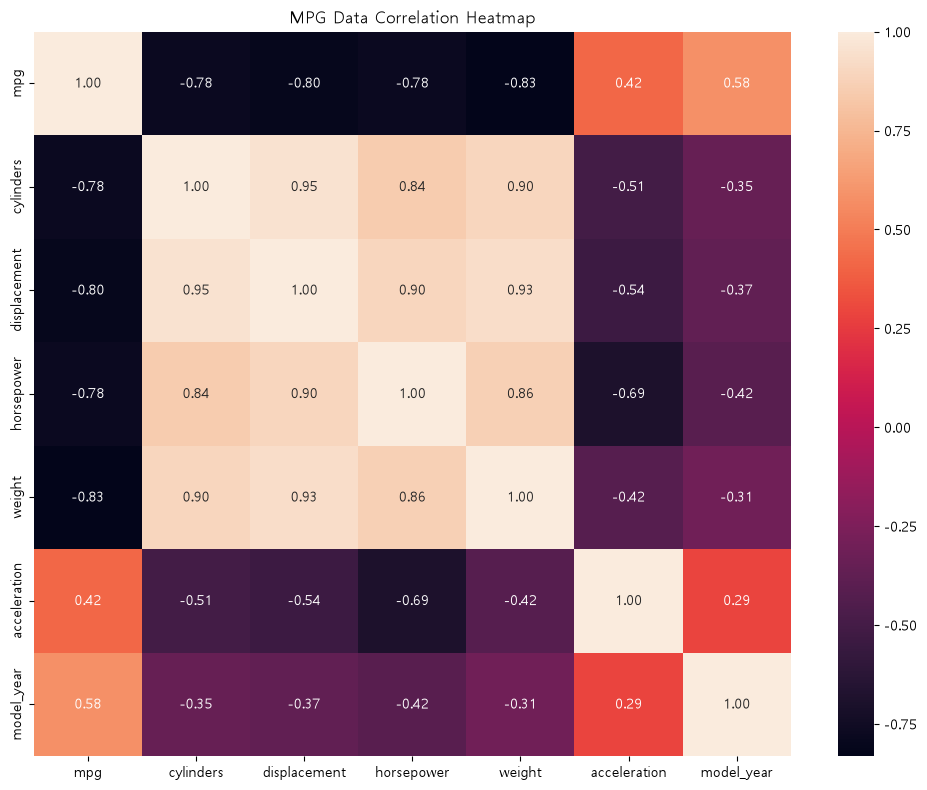

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# mpg 데이터 불러오기
mpg = sns.load_dataset("mpg")

# 데이터 확인
print(mpg.head())

# 숫자형 변수들의 상관계수 계산
corr = mpg.corr(numeric_only=True)

# 상관계수 행렬 확인
print(corr)

# Figure 생성
fig = plt.figure(figsize=(10, 8))

# Figure 안에 1개의 Axes 생성
axes1 = fig.add_subplot(1, 1, 1)

# 상관계수 행렬을 Heatmap으로 표현
sns.heatmap(
    corr,
    annot=True,       # 각 칸에 상관계수 숫자 표시
    fmt=".2f",        # 소수점 둘째 자리까지 표시
    ax=axes1
)

# 제목 설정
axes1.set_title("MPG Data Correlation Heatmap")

# 그래프 여백 정리
fig.tight_layout()

# 그래프 출력
plt.show()